In [5]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [7]:
colorlist = ["xkcd:magenta", "xkcd:blue green", "xkcd:grey", "xkcd:sky blue", "xkcd:light orange",
             "xkcd:grey blue", "xkcd:dark yellow", "xkcd:pale purple", "xkcd:coral",
             "xkcd:ocean blue", "xkcd:light olive", "xkcd:reddish brown", "xkcd:dark lavender", "xkcd:forrest green", 
             "xkcd:terracotta", "xkcd:light cyan", "xkcd:orchid", "xkcd:puke yellow", "xkcd:periwinkle blue"]

In [8]:
#Read in data
control = pd.read_csv('./2025_controltow_flux.csv')
array = pd.read_csv('./2025_arraytow_flux.csv')

#Setup datetime index
control = control.map(lambda x: np.nan if x == -9999 else x) #Convert -9999s to NaNs
#Create column of datetime objects from the 'TIMESTAMP COLUMN'
#Need to shift it 6 hours to put in local time (TIMESTAMP column is in UTC)
#I'm not sure if the timestamp is for the start or the end of the averaging period, we should check with Jonathan
#If it's the end, change the "hours = 6" to "hours = 5, minutes = 30"
control['dt_ts'] = pd.to_datetime(control['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
r = pd.date_range(start=dt.datetime(2025, 1, 1), end=control.dt_ts.max(), freq = '30min') 
control = control.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

#Array tower dataset
array = array.map(lambda x: np.nan if x == -9999 else x) #Convert -9999s to NaNs
array['dt_ts'] = pd.to_datetime(array['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6) #same note as above about timeshift
array = array.set_index('dt_ts').reindex(r).rename_axis('dt_ts')

In [9]:
control.columns

Index(['Unnamed: 0', 'TIMESTAMP', 'RECORD', 'Hs', 'tau', 'u_star', 'Ts_stdev',
       'Ts_Ux_cov', 'Ts_Uy_cov', 'Ts_Uz_cov', 'Ux_stdev', 'Ux_Uy_cov',
       'Ux_Uz_cov', 'Uy_stdev', 'Uy_Uz_cov', 'Uz_stdev', 'wnd_spd',
       'rslt_wnd_spd', 'wnd_dir_sonic', 'std_wnd_dir', 'wnd_dir_compass',
       'Ux_Avg', 'Uy_Avg', 'Uz_Avg', 'Ts_Avg', 'sonic_azimuth',
       'sonic_samples_Tot', 'diag_sonic_aggregate', 'no_sonic_head_Tot',
       'no_new_sonic_data_Tot', 'sonic_amp_l_f_Tot', 'sonic_amp_h_f_Tot',
       'sonic_sig_lck_f_Tot', 'sonic_del_T_f_Tot', 'sonic_aq_sig_f_Tot',
       'sonic_cal_err_f_Tot', 'Fc_wpl', 'LE_wpl', 'Hc', 'CO2_stdev',
       'CO2_Ux_cov', 'CO2_Uy_cov', 'CO2_Uz_cov', 'H2O_stdev', 'H2O_Ux_cov',
       'H2O_Uy_cov', 'H2O_Uz_cov', 'Tc_stdev', 'Tc_Ux_cov', 'Tc_Uy_cov',
       'Tc_Uz_cov', 'CO2_mean', 'H2O_mean', 'amb_tmpr_Avg', 'amb_press_mean',
       'Tc_mean', 'rho_a_mean', 'Fc_irga', 'LE_irga', 'CO2_wpl_LE',
       'CO2_wpl_H', 'H2O_wpl_LE', 'H2O_wpl_H', 'irga_samples

(array([187., 215., 314., 286., 301., 334., 357., 338., 234., 135., 143.,
        190., 229., 238., 264., 271., 394., 541., 431., 322., 357., 478.,
        399., 480., 467., 427., 310., 366., 430., 264.]),
 array([6.35376000e-02, 1.20611897e+01, 2.40588418e+01, 3.60564938e+01,
        4.80541459e+01, 6.00517980e+01, 7.20494501e+01, 8.40471022e+01,
        9.60447542e+01, 1.08042406e+02, 1.20040058e+02, 1.32037710e+02,
        1.44035363e+02, 1.56033015e+02, 1.68030667e+02, 1.80028319e+02,
        1.92025971e+02, 2.04023623e+02, 2.16021275e+02, 2.28018927e+02,
        2.40016579e+02, 2.52014231e+02, 2.64011883e+02, 2.76009535e+02,
        2.88007188e+02, 3.00004840e+02, 3.12002492e+02, 3.24000144e+02,
        3.35997796e+02, 3.47995448e+02, 3.59993100e+02]),
 <BarContainer object of 30 artists>)

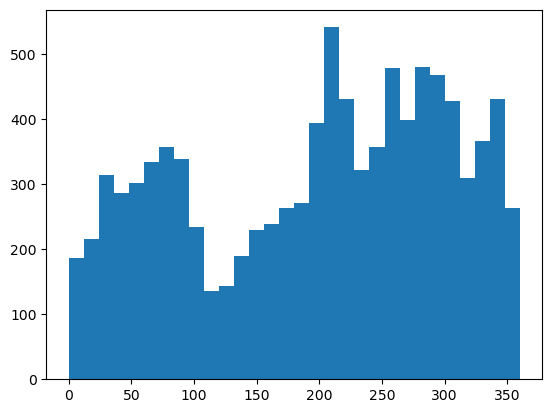

In [ ]:
startdate = dt.datetime(2025, 1, 1)
enddate = dt.datetime(2025, 7, 23)
plt.hist(control['wnd_dir_compass'][startdate:enddate], bins = 30);

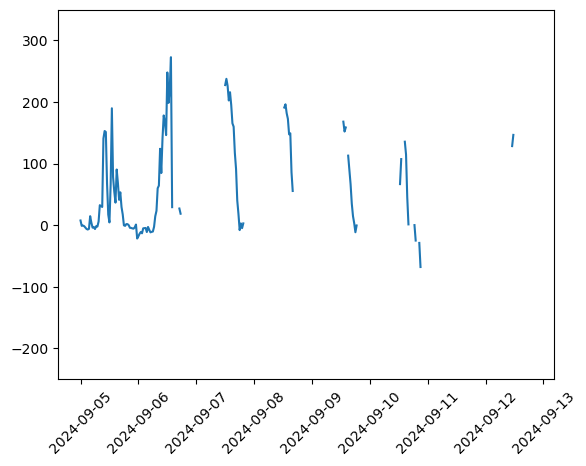

In [66]:
KSP = pd.read_csv('./2024_KSP_flux.csv')
KSP['dt_ts'] = pd.to_datetime(KSP['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
r = pd.date_range(start=dt.datetime(2024, 1, 1), end=KSP.dt_ts.max(), freq = '30min') 
KSP = KSP.set_index('dt_ts').reindex(r).rename_axis('dt_ts')
startdate = dt.datetime(2024, 9, 5)
enddate = dt.datetime(2024, 9, 13)
plt.plot(KSP['Hc'][startdate:enddate])
plt.ylim(-250, 350)
plt.xticks(rotation = 45);

In [54]:
KSP['Fc_wpl'][startdate:enddate]

dt_ts
2023-12-07 10:00:00         NaN
2023-12-07 10:30:00         NaN
2023-12-07 11:00:00         NaN
2023-12-07 11:30:00         NaN
2023-12-07 12:00:00         NaN
2023-12-07 12:30:00         NaN
2023-12-07 13:00:00         NaN
2023-12-07 13:30:00   -0.093166
2023-12-07 14:00:00   -0.036892
2023-12-07 14:30:00   -0.053904
2023-12-07 15:00:00   -0.028313
2023-12-07 15:30:00    0.001800
2023-12-07 16:00:00    0.029791
2023-12-07 16:30:00    0.021561
2023-12-07 17:00:00    0.063970
2023-12-07 17:30:00    0.057104
2023-12-07 18:00:00    0.035563
2023-12-07 18:30:00    0.065164
2023-12-07 19:00:00    0.075997
2023-12-07 19:30:00    0.077873
2023-12-07 20:00:00    0.055434
2023-12-07 20:30:00    0.051381
2023-12-07 21:00:00    0.089115
2023-12-07 21:30:00    0.073539
2023-12-07 22:00:00    0.078767
2023-12-07 22:30:00    0.071890
2023-12-07 23:00:00    0.080286
2023-12-07 23:30:00    0.078187
2023-12-08 00:00:00    0.079121
2023-12-08 00:30:00    0.056616
2023-12-08 01:00:00    0.055348
Fr

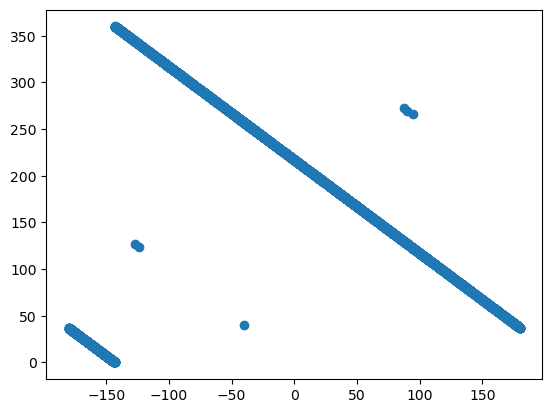

In [5]:
plt.scatter(array['wnd_dir_sonic'], array['wnd_dir_compass'])
# plt.hist(array['wnd_dir_sonic'])
# plt.hist(control['wnd_dir_sonic'])

C:\Users\emily\AppData\Local\Temp\ipykernel_22912\429566796.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  boxplot_data.append({'Bin': row[0], 'Value': value})


Text(0.5, 1.0, 'Control - 12pm to 6pm')

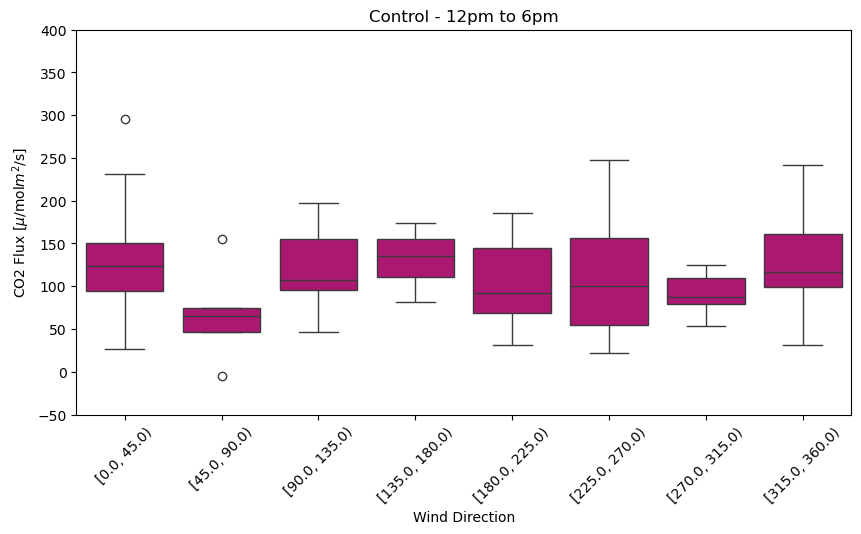

In [6]:
startdate = dt.datetime(2025, 5, 22)
enddate = dt.datetime(2025, 6, 13)
tow_dat = array
x = tow_dat['wnd_dir_compass'][startdate:enddate]

y = tow_dat['LE_wpl'][startdate:enddate]

x_use = x.where((x.index.hour>=12)&(x.index.hour<18))
# x_use = x

bins_array = np.linspace(0, 360, 9)

# Create bins
bins = pd.cut(x_use, bins=bins_array, right=False)

y_grpd = y.groupby(bins, observed = False).apply(list).reset_index(name = '0')

boxplot_data = []
for idx, row in y_grpd.iterrows():
    for value in row['0']:
        boxplot_data.append({'Bin': row[0], 'Value': value})
        
# Convert to DataFrame
boxplot_df = pd.DataFrame(boxplot_data)
        
fig, axs = plt.subplots(figsize=(10,5))
sns.boxplot(ax = axs, x='Bin', y='Value', data=boxplot_df, color = colorlist[0])

axs.set_xlabel('Wind Direction')
axs.set_ylabel('CO2 Flux [$\mu$/mol$m^2$/s]')
axs.set_ylim(-50, 400)
axs.tick_params(axis='x', labelrotation=45);

plt.title('Control - 12pm to 6pm')



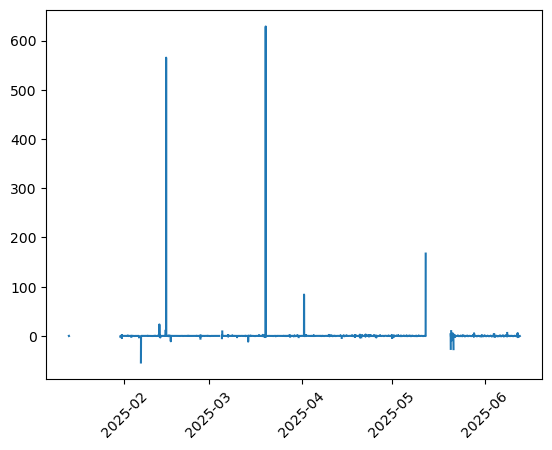

In [7]:
startdate = dt.datetime(2025, 5, 22)
enddate = dt.datetime(2025, 6, 13)
plt.plot(tow_dat['Fc_wpl'])
# plt.plot(tow_dat['Fc_wpl'].where((tow_dat['Fc_wpl']<1)&(tow_dat['Fc_wpl']>-1))[startdate:enddate])
# plt.ylim(-1, 1)
plt.xticks(rotation = 45);

Text(0.5, 1.0, 'Difference between control and array tower wind direction (sonic)')

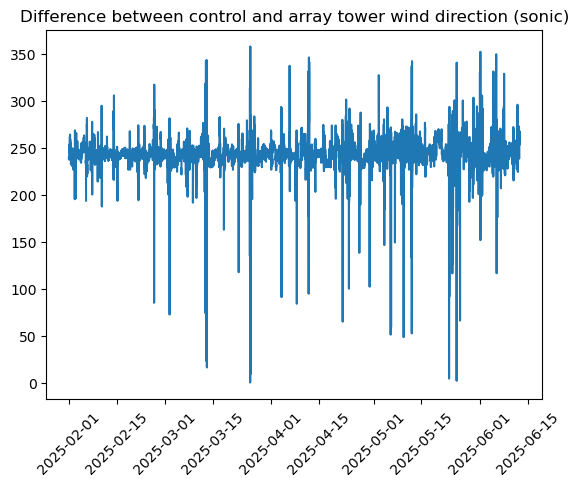

In [8]:
startdate = dt.datetime(2025, 2, 1)
enddate = dt.datetime(2025, 6, 13)
plt.plot(((control['wnd_dir_sonic'] - array['wnd_dir_sonic'][startdate:enddate]) + 360)%360)
plt.xticks(rotation = 45);
plt.title('Difference between control and array tower wind direction (sonic)')

In [9]:
control.columns

Index(['Unnamed: 0', 'TIMESTAMP', 'RECORD', 'Hs', 'tau', 'u_star', 'Ts_stdev',
       'Ts_Ux_cov', 'Ts_Uy_cov', 'Ts_Uz_cov', 'Ux_stdev', 'Ux_Uy_cov',
       'Ux_Uz_cov', 'Uy_stdev', 'Uy_Uz_cov', 'Uz_stdev', 'wnd_spd',
       'rslt_wnd_spd', 'wnd_dir_sonic', 'std_wnd_dir', 'wnd_dir_compass',
       'Ux_Avg', 'Uy_Avg', 'Uz_Avg', 'Ts_Avg', 'sonic_azimuth',
       'sonic_samples_Tot', 'diag_sonic_aggregate', 'no_sonic_head_Tot',
       'no_new_sonic_data_Tot', 'sonic_amp_l_f_Tot', 'sonic_amp_h_f_Tot',
       'sonic_sig_lck_f_Tot', 'sonic_del_T_f_Tot', 'sonic_aq_sig_f_Tot',
       'sonic_cal_err_f_Tot', 'Fc_wpl', 'LE_wpl', 'Hc', 'CO2_stdev',
       'CO2_Ux_cov', 'CO2_Uy_cov', 'CO2_Uz_cov', 'H2O_stdev', 'H2O_Ux_cov',
       'H2O_Uy_cov', 'H2O_Uz_cov', 'Tc_stdev', 'Tc_Ux_cov', 'Tc_Uy_cov',
       'Tc_Uz_cov', 'CO2_mean', 'H2O_mean', 'amb_tmpr_Avg', 'amb_press_mean',
       'Tc_mean', 'rho_a_mean', 'Fc_irga', 'LE_irga', 'CO2_wpl_LE',
       'CO2_wpl_H', 'H2O_wpl_LE', 'H2O_wpl_H', 'irga_samples

In [15]:
# fastdat = pd.read_csv('C:\\Users\\emily\\EddyPro\\Fast_data\\20250617\\agrivoltaics2_ts_data_2025_06_17_0000.dat', header = [1], skiprows = [2, 3])

In [17]:
# fn_p1 = 'C:\\Users\\emily\\EddyPro\\Fast_data\\20250101\\agrovoltaics1_ts_data_2025_01_01_'
# fn_p3 = '30.dat'
# for i in range(24):
#     filename = fn_p1 + str(i).zfill(2) + fn_p3
#     a = pd.read_csv(filename, header = [1], skiprows = [2, 3])
#     print(a.shape)

In [ ]:
r1 = (pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\EddyPro\\EP_Output\
\\Run1\\eddypro_KSC_fluxnet_2025-06-19T101312_exp.csv'))

r2 = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\EddyPro\\EP_Output\
\\Run2_1m\\eddypro_KSC_fluxnet_2025-06-19T101709_exp.csv')

r3 = pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\EddyPro\\EP_Output\
\\Run3_0.1m\\eddypro_KSC_fluxnet_2025-06-19T102432_exp.csv')

In [18]:
# r1 = r1.where(r1!=-9999)
# r2 = r2.where(r2!=-9999)
# r3 = r3.where(r3!=-9999)


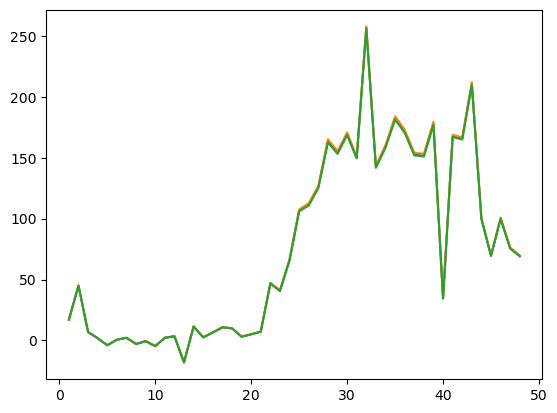

In [ ]:
# var = 'LE'

# for run in [r1, r2, r3]:
#     plt.plot(run[var])

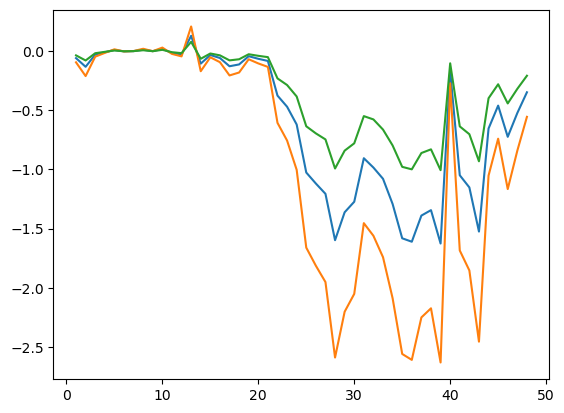

In [ ]:
# plt.plot(r1[var] - r2[var])
# plt.plot(r3[var] - r2[var])
# plt.plot(r3[var] - r1[var])

In [ ]:
pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\EddyPro\\Fast_data\\20250617\\agrivoltaics2_netrad_data_2025_06_17_2331.dat', header = [1, 2, 3])

,TIMESTAMP,RECORD,apSWIn_Avg,apSWOut_Avg,apLWIn_Avg,apLWOut_Avg,apNETSW_Avg,apNETLW_Avg,apNETRAD_Avg,apSWIn_mV_Avg,apSWOut_mV_Avg,apLWIn_mv_Avg,apLWIn_temp_Avg,apLWOut_mv_Avg,apLWOut_temp_Avg,AirTC_Avg,RH_Avg
,TS,RN,W/m^2,W/m^2,W/m^2,W/m^2,W/m^2,W/m^2,W/m^2,millivolts,millivolts,millivolts,degC,millivolts,degC,Deg C,%
,Unnamed: 0_level_2,Unnamed: 1_level_2,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg,Avg
0,2025-06-17 23:31:00,202974,250.6983,35.05167,374.6167,463.3816,215.5750,-88.76000,126.81330,13.199670,4.863333,-11.39383,30.92167,-1.624333,29.94000,28.54,51.04
1,2025-06-17 23:32:00,202975,249.9317,34.89666,374.5350,462.6300,215.0433,-88.11499,126.92830,13.147670,4.828166,-11.39817,30.85500,-1.654667,29.87833,28.57,49.28
2,2025-06-17 23:33:00,202976,199.2283,35.61500,374.9250,462.5933,202.6400,-87.75000,114.88830,11.777830,4.945667,-11.35267,30.86167,-1.662333,29.89500,28.57,48.97
3,2025-06-17 23:34:00,202977,246.6266,34.91667,374.6383,462.5950,211.7783,-87.86500,123.91330,13.009670,4.839167,-11.40717,30.91166,-1.693333,29.94167,28.59,49.11
4,2025-06-17 23:35:00,202978,242.7983,34.18000,374.2500,462.3567,208.5083,-87.98833,120.52000,12.777330,4.711833,-11.43983,30.89166,-1.706167,29.92167,28.59,50.00
5,2025-06-17 23:36:00,202979,241.1483,34.19667,374.4400,462.4933,206.7316,-88.05499,118.67670,12.693830,4.750667,-11.41800,30.89333,-1.685000,29.92333,28.58,50.65
6,2025-06-17 23:37:00,202980,214.3766,33.39666,378.1816,462.8916,183.4483,-84.64333,98.80332,10.183830,4.629667,-11.03400,31.00667,-1.714500,30.01000,28.59,51.96
7,2025-06-17 23:38:00,202981,237.6467,33.79667,373.9767,462.8933,204.0583,-89.10999,114.95000,12.522670,4.643667,-11.57317,31.03333,-1.726667,30.05333,28.65,50.40


In [4]:
pd.read_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\DFRC\\MiscData\\Kernza\\20240327\\Kernza_Flux_AmeriFluxFormat_2024_03_27_0530.dat', header = [1, 2, 3])

,TIMESTAMP,RECORD,TIMESTAMP_START,TIMESTAMP_END,CO2,CO2_SIGMA,H2O,H2O_SIGMA,FC,FC_SSITC_TEST,LE,LE_SSITC_TEST,ET,ET_SSITC_TEST,H,H_SSITC_TEST,G,SG,FETCH_MAX,FETCH_90,FETCH_55,FETCH_40,WD,WS,WS_MAX,USTAR,ZL,TAU,TAU_SSITC_TEST,MO_LENGTH,U,U_SIGMA,V,V_SIGMA,W,W_SIGMA,PA,TA_1_1_1,RH_1_1_1,T_DP_1_1_1,TA_2_1_1,RH_2_1_1,T_DP_2_1_1,TA_3_1_1,RH_3_1_1,T_DP_3_1_1,VPD,T_SONIC,T_SONIC_SIGMA,PBLH,SWC_1_1_1,SWC_2_1_1,TS_1_1_1,TS_2_1_1,ALB,NETRAD,SW_IN,SW_OUT,LW_IN,LW_OUT
,TS,RN,Unnamed: 2_level_1,Unnamed: 3_level_1,umolCO2 mol-1,umolCO2 mol-1,mmolH2O mol-1,mmolH2O mol-1,umolCO2 m-2 s-1,adimensional,W m-2,adimensional,mm hour-1,adimensional,W m-2,adimensional,W m-2,W m-2,m,m,m,m,decimal degrees,m s-1,m s-1,m s-1,adimensional,kg m-1 s-2,adimensional,m,m s-1,m s-1,m s-1,m s-1,m s-1,m s-1,kPa,deg C,%,deg C,deg C,%,deg C,deg C,%,deg C,hPa,deg C,deg C,m,%,%,deg C,deg C,%,W m-2,W m-2,W m-2,W m-2,W m-2
,Unnamed: 0_level_2,Unnamed: 1_level_2,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Smp,Avg,Avg,Avg,Avg,Smp,Smp,Avg,Smp,Smp,Smp
0,2024-03-27 05:30:00,1031,202403270500,202403270530,428.0714,0.312121,2.831245,0.056449,1.614807,9,19.15614,9,0.027683,9,-0.023615,9,NAN,NAN,19.21695,53.14728,27.33072,20.68468,351.9101,3.514471,10.14666,0.338144,-0.000532,0.140780,4,-3090.541,3.247246,1.332745,0,1.309010,-1.862645e-09,0.571094,98.10015,-2.797629,54.05296,-10.80369,4.175778,33.49501,-10.48278,-2.815294,71.60801,-7.225809,5.499157,4.424984,0.042830,1000,NAN,NAN,4.670112,550.3276,0,-18.11372,-0.858813,0.353833,287.9036,304.8046
1,2024-03-27 06:00:00,1032,202403270530,202403270600,427.7407,0.328986,2.705139,0.072186,1.513463,1,23.30424,1,0.033670,1,2.568903,4,NAN,NAN,20.98704,58.02734,29.84821,22.58998,343.4215,4.604471,13.03336,0.425470,-0.000973,0.223174,9,-1689.620,4.304400,1.653100,0,1.661441,0.000000e+00,0.643638,98.14386,-3.023962,52.54736,-11.37054,3.949854,32.53135,-11.05088,-3.042232,70.49028,-7.648189,5.490816,4.187854,0.075979,1000,NAN,NAN,4.519005,578.5532,0,-18.61618,-0.943266,0.195369,286.3358,303.8133
